In [ ]:
import shutil
import numpy as np
import wave
from pathlib import Path
from tqdm.auto import tqdm
import py7zr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

RAW_DIR = Path('../data/raw')
AUDIO_ROOT = RAW_DIR / 'train'/ 'audio'
LIST_DIR = RAW_DIR / 'train'
DATA_DIR = Path('../data')

TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR = DATA_DIR / 'test'
NOISE_DIR = DATA_DIR / '_background_noise_'

for d in [TRAIN_DIR, VALID_DIR, TEST_DIR, NOISE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [2]:
#Note -> put train.7z in data/raw before running this cell
print("Unpacking train.7z ...")
with py7zr.SevenZipFile(RAW_DIR / 'train.7z', mode='r') as z:
    z.extractall(path=RAW_DIR)

print("Done!")
print(f"Content of {AUDIO_ROOT}:", [p.name for p in AUDIO_ROOT.iterdir()])

Unpacking train.7z ...
Done!
Content of ../data/raw/train/audio: ['right', 'eight', 'cat', 'tree', 'bed', 'happy', 'go', 'dog', 'no', 'wow', 'nine', 'left', 'stop', 'three', '_background_noise_', 'sheila', 'one', 'bird', 'zero', 'seven', 'up', 'marvin', 'two', 'house', 'down', 'six', 'yes', 'on', 'five', 'off', 'four']


In [3]:
assert AUDIO_ROOT.exists(), f"{AUDIO_ROOT} not found"
assert (LIST_DIR / 'validation_list.txt').exists(), "Missing validation_list.txt"
assert (LIST_DIR / 'testing_list.txt').exists(), "Missing testing_list.txt"

word_folders = sorted([p.name for p in AUDIO_ROOT.iterdir() if p.is_dir()])
print(f'Word folders found ({len(word_folders)}): {word_folders}')

def read_list(path: Path) -> set:
    with open(path) as f:
        return {line.strip() for line in f if line.strip()}
    
valid_set = read_list(LIST_DIR / 'validation_list.txt')
test_set = read_list(LIST_DIR / 'testing_list.txt')

Word folders found (31): ['_background_noise_', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'four', 'go', 'happy', 'house', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'wow', 'yes', 'zero']


#### Splitting data into train/test/valid

In [4]:
BACKGROUND = '_background_noise_'
counts = {'train': 0, 'valid': 0, 'test': 0, 'background': 0}
all_wavs = list(AUDIO_ROOT.rglob('*.wav'))
print(f"Total .wav files: {len(all_wavs):,}")

Total .wav files: 64,727


In [5]:
BACKGROUND = '_background_noise_'
counts = {'train': 0, 'valid': 0, 'test': 0, 'background': 0}

all_wavs = list(AUDIO_ROOT.rglob('*.wav'))
print(f'Total .wav files: {len(all_wavs):,}')

for wav in tqdm(all_wavs, desc='Splitting'):
    word = wav.parent.name #name of the command (folder name)
    rel = f'{word}/{wav.name}' #file path relative to audio/

    if word == BACKGROUND:
        dst = NOISE_DIR / wav.name
        if not dst.exists():
            shutil.copy2(wav, dst)
        counts['background'] += 1
        continue

    if rel in test_set:
        split_dir = TEST_DIR
        counts['test'] += 1
    elif rel in valid_set:
        split_dir = VALID_DIR
        counts['valid'] += 1
    else:
        split_dir = TRAIN_DIR
        counts['train'] += 1

    dst_dir = split_dir / word
    dst_dir.mkdir(exist_ok=True)
    dst = dst_dir / wav.name
    if not dst.exists():
        shutil.copy2(wav, dst)

print('\nSplit summary:')
for k, v in counts.items():
    print(f'  {k:<12}: {v:,}')

Total .wav files: 64,727


Splitting:   0%|          | 0/64727 [00:00<?, ?it/s]


Split summary:
  train       : 51,088
  valid       : 6,798
  test        : 6,835
  background  : 6


#### Expand silence — chop background noise into 1s clips
Background noise files are long recordings (~60s each, max 90s).  
We cut them into 1s clips and place them in `train/silence/` so the model has enough silence examples.

In [7]:
SILENCE_DIR  = TRAIN_DIR / 'silence'
SILENCE_DIR.mkdir(exist_ok=True)

SAMPLE_RATE = 16000
CLIP_SAMPLES = SAMPLE_RATE  #1 second

noise_files = sorted(NOISE_DIR.glob('*.wav'))
print(f'Background noise files: {len(noise_files)}')

clip_idx = 0
for noise_file in noise_files:
    with wave.open(str(noise_file), 'r') as wf:
        sampwidth = wf.getsampwidth()
        framerate = wf.getframerate()
        n_frames = wf.getnframes()
        n_ch = wf.getnchannels()
        raw = wf.readframes(n_frames)

    dtype = np.int16 if sampwidth == 2 else np.int8
    samples = np.frombuffer(raw, dtype=dtype)
    if n_ch > 1:
        samples = samples[::n_ch]

    if framerate != SAMPLE_RATE:
        print(f'WARNING: {noise_file.name} is {framerate}Hz not {SAMPLE_RATE}Hz')

    n_clips = len(samples) // CLIP_SAMPLES
    for i in range(n_clips):
        chunk = samples[i * CLIP_SAMPLES : (i + 1) * CLIP_SAMPLES]
        out_path = SILENCE_DIR / f'silence_{clip_idx:05d}.wav'
        if not out_path.exists():
            with wave.open(str(out_path), 'w') as wf_out:
                wf_out.setnchannels(1)
                wf_out.setsampwidth(2)
                wf_out.setframerate(SAMPLE_RATE)
                wf_out.writeframes(chunk.astype(np.int16).tobytes())
        clip_idx += 1

print(f'Generated {clip_idx} silence clips in {SILENCE_DIR}')

Background noise files: 6
Generated 398 silence clips in ../data/train/silence


In [8]:
SILENCE_VALID_DIR = VALID_DIR / 'silence'
SILENCE_VALID_DIR.mkdir(exist_ok=True)

np.random.seed(42)
clip_idx = 0
for noise_file in noise_files:
    with wave.open(str(noise_file), 'r') as wf:
        sampwidth = wf.getsampwidth()
        n_frames = wf.getnframes()
        n_ch = wf.getnchannels()
        raw = wf.readframes(n_frames)

    dtype = np.int16 if sampwidth == 2 else np.int8
    samples = np.frombuffer(raw, dtype=dtype)
    if n_ch > 1:
        samples = samples[::n_ch]

    #sampling 5 random 1s clips from each noise file for validation instead of taking all possible clips
    n_possible = len(samples) // CLIP_SAMPLES
    chosen = np.random.choice(n_possible, size=min(5, n_possible), replace=False)
    
    for i in chosen:
        chunk = samples[i * CLIP_SAMPLES : (i + 1) * CLIP_SAMPLES]
        out_path = SILENCE_VALID_DIR / f'silence_{clip_idx:05d}.wav'
        if not out_path.exists():
            with wave.open(str(out_path), 'w') as wf_out:
                wf_out.setnchannels(1)
                wf_out.setsampwidth(2)
                wf_out.setframerate(SAMPLE_RATE)
                wf_out.writeframes(chunk.astype(np.int16).tobytes())
        clip_idx += 1

print(f'Generated {clip_idx} silence clips in {SILENCE_VALID_DIR}')

Generated 30 silence clips in ../data/valid/silence


In [10]:
SILENCE_TEST_DIR = TEST_DIR / 'silence'
SILENCE_TEST_DIR.mkdir(exist_ok=True)

np.random.seed(43)
clip_idx = 0
for noise_file in noise_files:
    with wave.open(str(noise_file), 'r') as wf:
        sampwidth = wf.getsampwidth()
        n_frames  = wf.getnframes()
        n_ch = wf.getnchannels()
        raw = wf.readframes(n_frames)

    dtype = np.int16 if sampwidth == 2 else np.int8
    samples = np.frombuffer(raw, dtype=dtype)
    if n_ch > 1:
        samples = samples[::n_ch]

    n_possible = len(samples) // CLIP_SAMPLES
    chosen = np.random.choice(n_possible, size=min(5, n_possible), replace=False)

    for i in chosen:
        chunk = samples[i * CLIP_SAMPLES : (i + 1) * CLIP_SAMPLES]
        out_path = SILENCE_TEST_DIR / f'silence_{clip_idx:05d}.wav'
        if not out_path.exists():
            with wave.open(str(out_path), 'w') as wf_out:
                wf_out.setnchannels(1)
                wf_out.setsampwidth(2)
                wf_out.setframerate(SAMPLE_RATE)
                wf_out.writeframes(chunk.astype(np.int16).tobytes())
        clip_idx += 1

print(f'Generated {clip_idx} silence clips in {SILENCE_TEST_DIR}')

Generated 30 silence clips in ../data/test/silence


Label mapping: raw folder → 12 model classes

| raw folder | model label |
|---|---|
| yes / no / up / down / left / right / on / off / stop / go | same word |
| zero / one / ... / nine / bed / bird / cat / ... (20 folders) | `unknown` |
| silence/ (generated above) | `silence` |

In [11]:
TARGET_WORDS = {'yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go'}

def map_label(word: str) -> str:
    if word == 'silence':
        return 'silence'
    elif word in TARGET_WORDS:
        return word
    else:
        return 'unknown'

rows = []
for split, split_dir in [('train', TRAIN_DIR), ('valid', VALID_DIR), ('test', TEST_DIR)]:
    for word_dir in sorted(split_dir.iterdir()):
        n = len(list(word_dir.glob('*.wav')))
        rows.append({
            'split': split,
            'word':  word_dir.name,
            'label': map_label(word_dir.name),
            'count': n
        })

df = pd.DataFrame(rows)

label_counts = (df[df.split == 'train'].groupby('label')['count'].sum().sort_values(ascending=False))

print('Train — model classes')
print(label_counts.to_string())
print(f'\nTotal: {label_counts.sum():,}')

Train — model classes
label
unknown    32550
stop        1885
on          1864
go          1861
yes         1860
no          1853
right       1852
up          1843
down        1842
left        1839
off         1839
silence      398

Total: 51,486


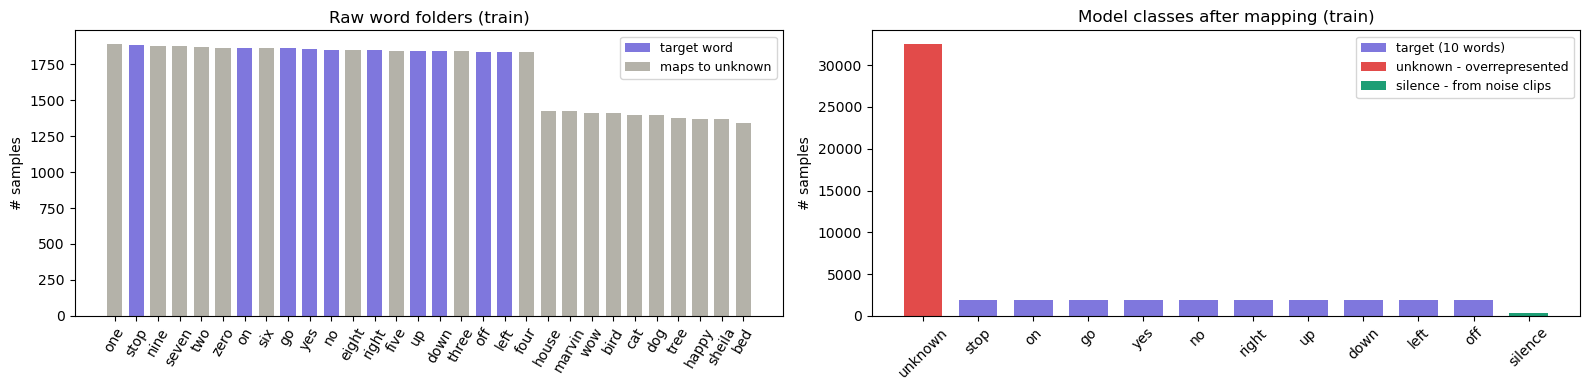

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

train_raw = (
    df[(df.split == 'train') & (~df.word.isin(['silence', '_background_noise_']))]
    .set_index('word')['count']
    .sort_values(ascending=False)
)
colors_raw = ['#7F77DD' if w in TARGET_WORDS else '#B4B2A9' for w in train_raw.index]

axes[0].bar(train_raw.index, train_raw.values, color=colors_raw, width=0.7)
axes[0].set_title('Raw word folders (train)')
axes[0].set_ylabel('# samples')
axes[0].tick_params(axis='x', rotation=60)
axes[0].legend(handles=[
    Patch(facecolor='#7F77DD', label='target word'),
    Patch(facecolor='#B4B2A9', label='maps to unknown'),
], fontsize=9)

colors_mapped = [
    '#E24B4A' if l == 'unknown' else
    '#1D9E75' if l == 'silence' else
    '#7F77DD'
    for l in label_counts.index
]
axes[1].bar(label_counts.index, label_counts.values, color=colors_mapped, width=0.7)
axes[1].set_title('Model classes after mapping (train)')
axes[1].set_ylabel('# samples')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(handles=[
    Patch(facecolor='#7F77DD', label='target (10 words)'),
    Patch(facecolor='#E24B4A', label='unknown - overrepresented'),
    Patch(facecolor='#1D9E75', label='silence - from noise clips'),
], fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
print('Final structure')
for split, split_dir in [('train', TRAIN_DIR), ('valid', VALID_DIR), ('test', TEST_DIR)]:
    n_classes = sum(1 for d in split_dir.iterdir() if d.is_dir())
    n_files = sum(len(list(d.glob('*.wav'))) for d in split_dir.iterdir() if d.is_dir())
    print(f'{split:<6}: {n_files:>6,} files  |  {n_classes} class folders')

n_noise = len(list(NOISE_DIR.glob('*.wav')))
n_silence = len(list(SILENCE_DIR.glob('*.wav')))
print(f'noise: {n_noise} raw background files')
print(f'silence: {n_silence} generated 1s clips (in train/silence/)')

Final structure
train : 51,486 files  |  31 class folders
valid :  6,828 files  |  31 class folders
test  :  6,865 files  |  31 class folders
noise: 6 raw background files
silence: 398 generated 1s clips (in train/silence/)
